# Native skeleton pre/post comparison

Compare **mean**, **pointwise MLP**, and **GraphTransformer (GT)** on the native **bin16 / k17 / confidence ≥0.7** cohort. Each architecture is compared across pre only, a matched-width presynaptic-mean control, and pre + post, using the existing fold-0 cell splits and 30-epoch settings.

| Condition | Input to the shared ResNet classification trunk |
|---|---|
| Pre only | Pooled presynaptic representation |
| Pre + raw pre mean | Pooled presynaptic representation concatenated with the 64-dimensional mean of raw presynaptic embeddings |
| Pre + post | Pooled presynaptic representation concatenated with the matched 64-dimensional postsynaptic embedding |

Postsynaptic features enter **after pooling**, leaving the presynaptic encoder unchanged. All three groups exclude unresolved roots and empty postsynaptic masks before applying the same presynaptic-window deduplication. Different postsynaptic points **do not make identical presynaptic node sets unique**; the first eligible site supplies the postsynaptic vector.

The existing training procedure selects the best epoch using the held-out fold and reports metrics on that same fold. These are exploratory comparisons, not a separate untouched test set. Figures are separated by fold; missing runs are shown as pending.

The mean control and pre + post have identical classifier widths and parameter counts: **128 dimensions for mean**, **192 for MLP/GT**. The control adds no new observations, though it gives learned encoders a direct raw-feature skip connection. **Window macro F1 is the primary outcome**; cell-vote metrics are secondary context.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'results/presynaptic/native_skeletons_pre_post').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.presynaptic.native_skeletons_pre_post.comparison import (
    RESULT_ROOT, ARCHITECTURES, ARCH_LABELS, CONDITIONS, LABELS,
    load_training_curves, load_summaries, metric_deltas,
    plot_training_curves, plot_metric_comparison, plot_per_class_recall, plot_confusions,
)

def show_fold_figure(fig, fold):
    if fig is not None:
        title = fig._suptitle.get_text() if fig._suptitle is not None else ''
        fig.suptitle(f'Fold {fold} · {title}')
        display(fig)
        plt.close(fig)

print(RESULT_ROOT)

/orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/results/presynaptic/native_skeletons_pre_post/scale16/k17/conf0.7


## Training progress

Rows correspond to architectures; columns show training loss, held-out window macro F1, and held-out cell macro F1. Rerun the notebook to refresh progress from saved epoch CSV files.

Fold 0


,architecture,condition,epoch,train_loss,window_macro_f1,cell_macro_f1
29,graph_transformer,pre_only,29,0.249595,0.658173,0.817637
119,graph_transformer,pre_post,29,0.225068,0.677413,0.766681
59,mean,pre_only,29,0.255246,0.658708,0.817637
138,mean,pre_post,18,0.248570,0.672053,0.748536
89,pointwise_mlp,pre_only,29,0.246201,0.667320,0.822307
155,pointwise_mlp,pre_post,16,0.244758,0.639422,0.678446


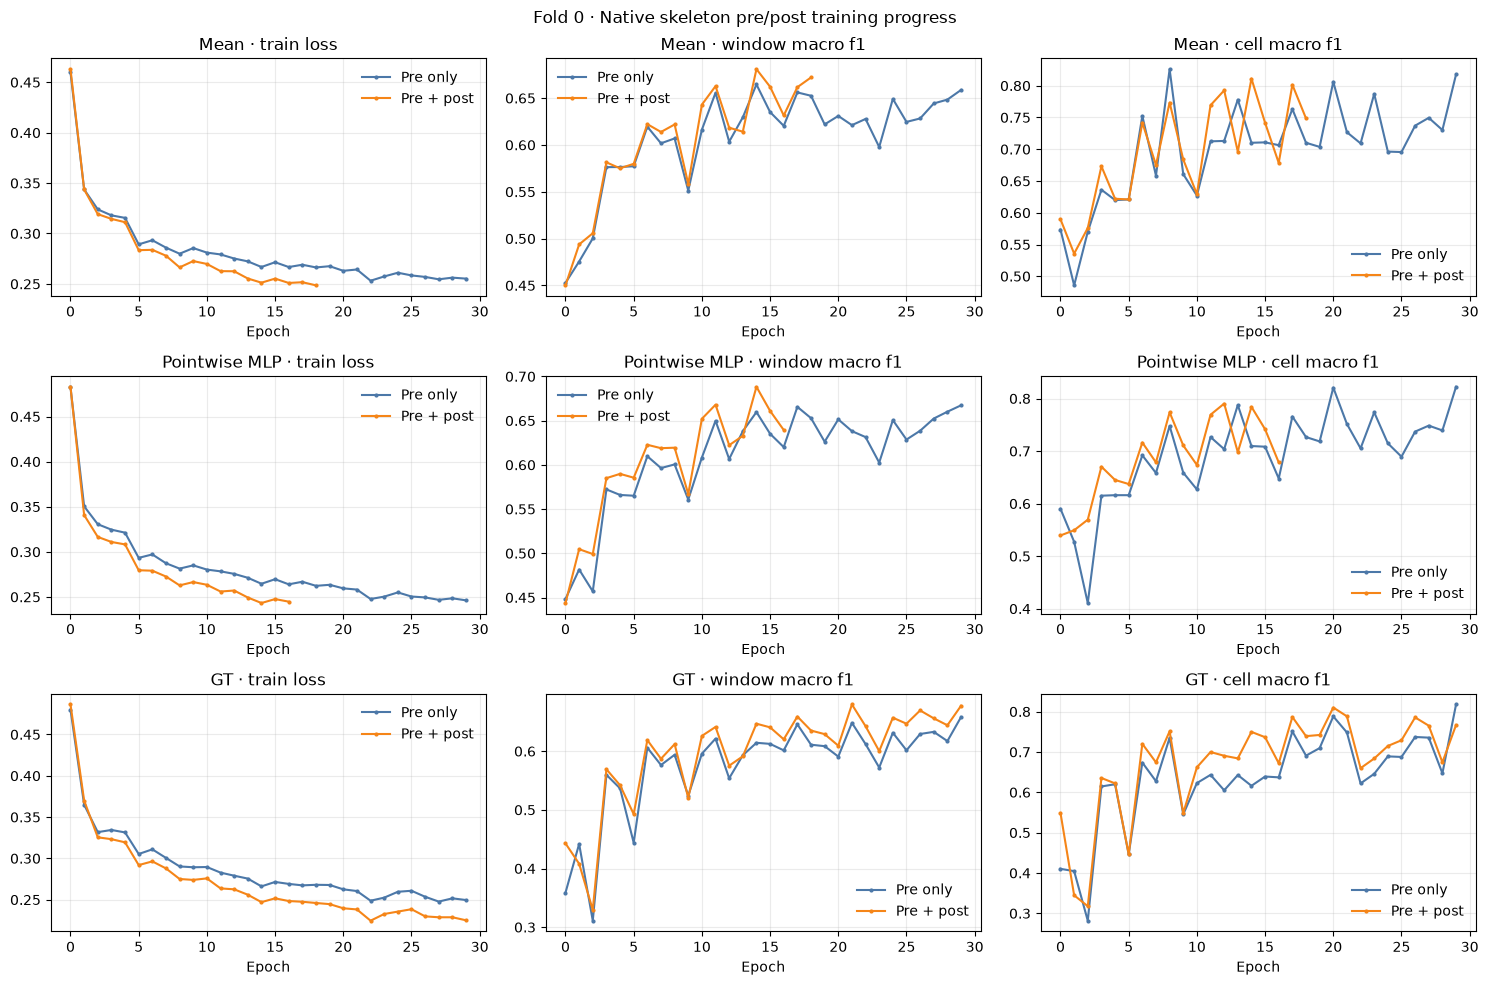

In [2]:
curves = load_training_curves()
if curves.empty:
    print('No completed epochs yet.')
else:
    for fold, fold_curves in curves.groupby('fold', sort=True):
        print(f'Fold {fold}')
        latest = (fold_curves.sort_values('epoch')
                  .groupby(['architecture', 'condition', 'run'], observed=True).tail(1))
        display(latest[['architecture', 'condition', 'epoch', 'train_loss',
                        'window_macro_f1', 'cell_macro_f1']].sort_values(['architecture', 'condition']))
        show_fold_figure(plot_training_curves(fold_curves), fold)

## Held-out metrics

Final result JSON files take precedence. Until a model finishes, its saved best-so-far metrics are shown with **complete=False**. Window macro F1 is the primary metric. Cell metrics reflect majority voting over retained presynaptic windows; window metrics measure local predictions.

Awaiting metrics: [('graph_transformer', 'pre_mean_control'), ('mean', 'pre_mean_control'), ('pointwise_mlp', 'pre_mean_control')]


,fold,architecture,condition,complete,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1
0,0,graph_transformer,pre_only,True,29,0.847663,0.657310,0.764748,0.658173,0.958217,0.777174,0.962059,0.817637
3,0,graph_transformer,pre_post,True,21,0.847017,0.692773,0.712414,0.679625,0.947075,0.744928,0.944395,0.788273
1,0,mean,pre_only,True,14,0.853487,0.640821,0.700777,0.664596,0.933148,0.702174,0.941319,0.710159
4,0,mean,pre_post,False,14,0.859869,0.652524,0.728183,0.680931,0.958217,0.776087,0.958967,0.811203
2,0,pointwise_mlp,pre_only,True,29,0.850833,0.666410,0.760860,0.666862,0.958217,0.784897,0.957709,0.822307
5,0,pointwise_mlp,pre_post,False,14,0.868853,0.661017,0.737231,0.688257,0.947075,0.751563,0.946953,0.784257


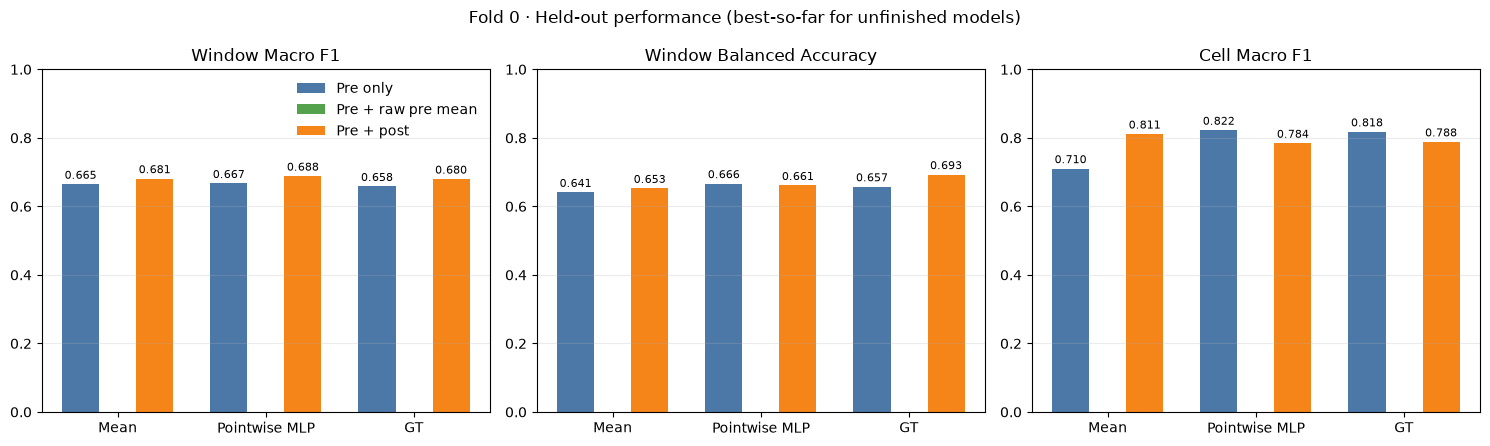

In [3]:
summary, payloads = load_summaries()
folds = sorted(summary.fold.unique()) if not summary.empty else []
if summary.empty:
    print('Awaiting saved best-epoch or final metrics.')
else:
    for fold in folds:
        fold_summary = summary[summary.fold == fold]
        display(fold_summary.drop(columns='run').sort_values(['architecture', 'condition']))
        expected = {(a, c) for a in ARCHITECTURES for c in CONDITIONS}
        present = set(zip(fold_summary.architecture, fold_summary.condition))
        print('Awaiting metrics:', sorted(expected - present) or 'none')
        show_fold_figure(plot_metric_comparison(fold_summary), fold)

## Benefit of postsynaptic information

Subtract each reference (**pre only** and **pre + raw pre mean**) from **pre + post**, within the same architecture and fold. The comparison against raw pre mean controls classifier input width and parameter count. Positive window macro F1 differences favor postsynaptic information. `both_complete=False` marks provisional comparisons.

In [4]:
deltas = metric_deltas(summary)
if deltas.empty:
    print('Deltas require both conditions for the same architecture and fold.')
else:
    primary = ['fold', 'architecture', 'reference', 'both_complete', 'window_macro_f1',
               'window_balanced_accuracy', 'window_macro_precision', 'window_accuracy']
    display(deltas[primary])

,fold,architecture,reference,both_complete,window_macro_f1,window_balanced_accuracy,window_macro_precision,window_accuracy
0,0,graph_transformer,pre_only,True,0.021452,0.035463,-0.052334,-0.000646
1,0,mean,pre_only,False,0.016335,0.011702,0.027406,0.006382
2,0,pointwise_mlp,pre_only,False,0.021395,-0.005393,-0.023629,0.018020


## Per-class recall

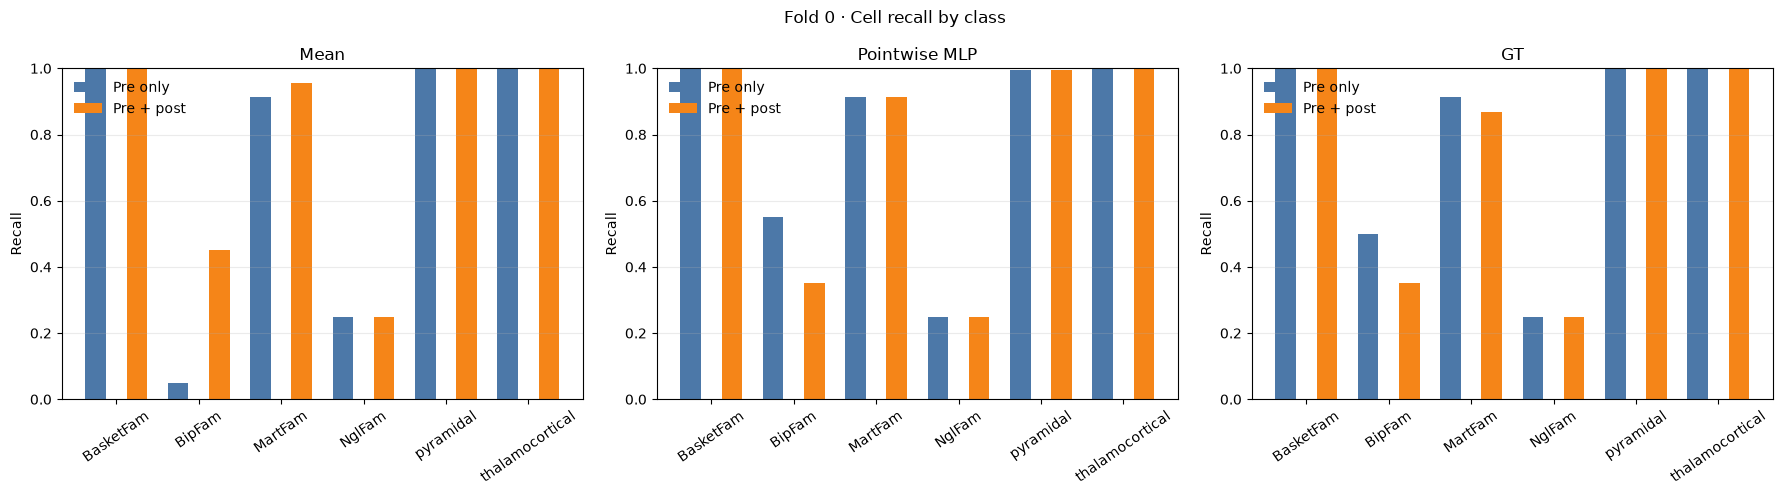

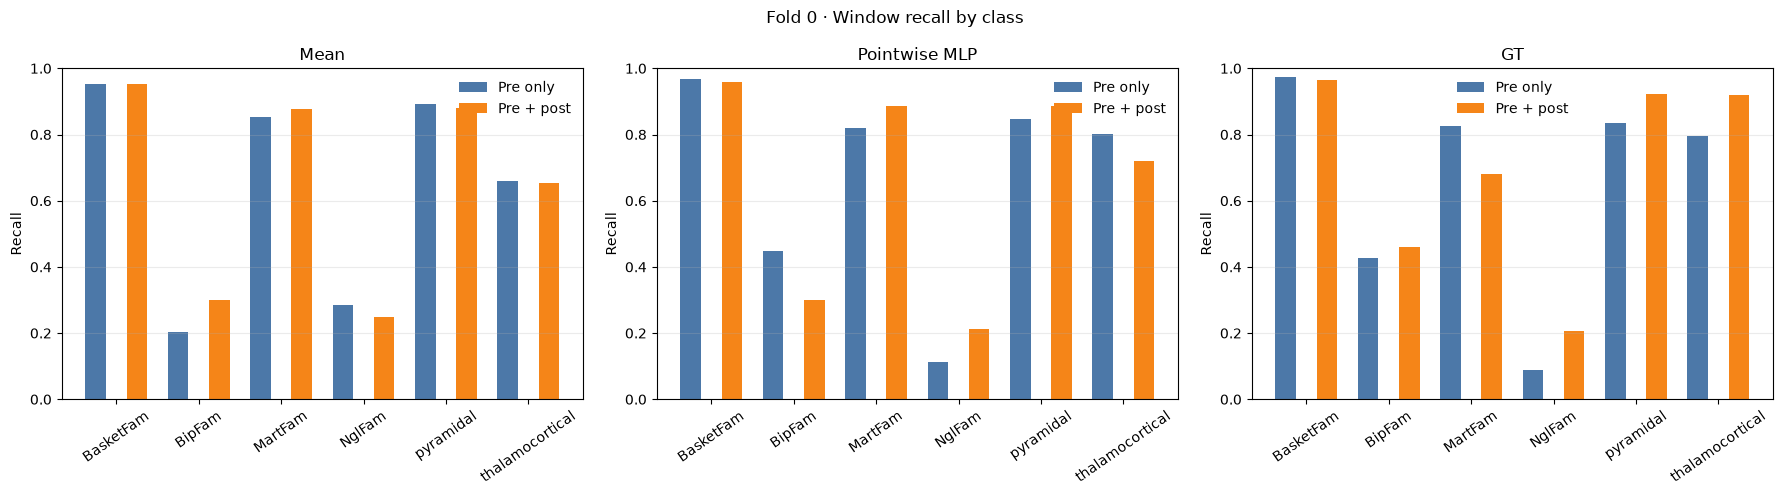

In [5]:
for fold in folds:
    for scope in ('cell', 'window'):
        show_fold_figure(plot_per_class_recall(payloads, fold, scope=scope), fold)

## Confusion matrices

One figure per architecture and fold. Window matrices are in the first row, cell matrices in the second. Each entry shows the fraction within its true class and the raw count in parentheses.

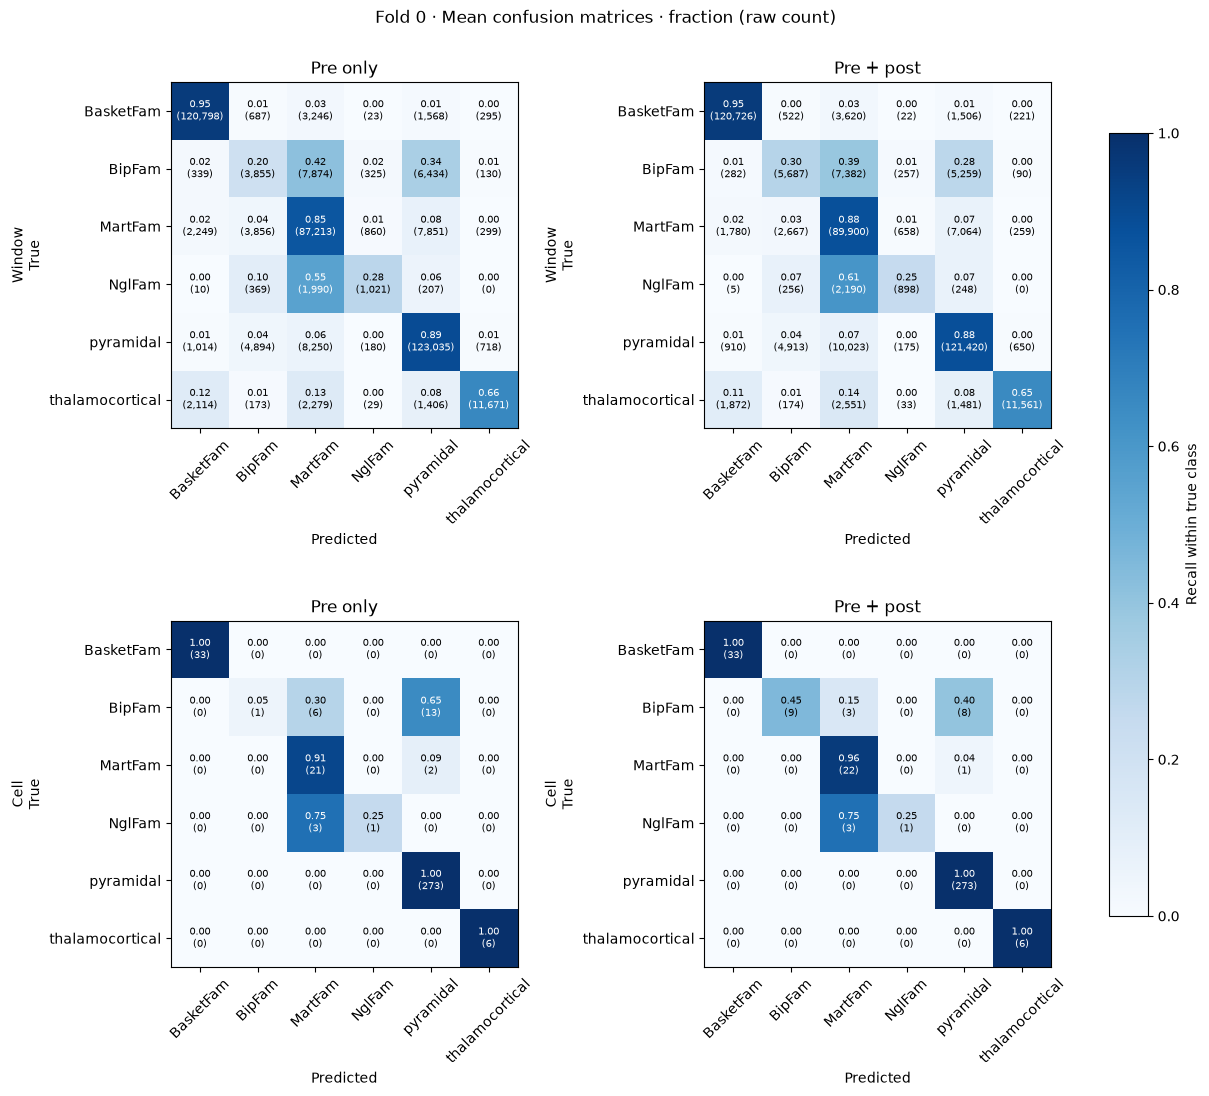

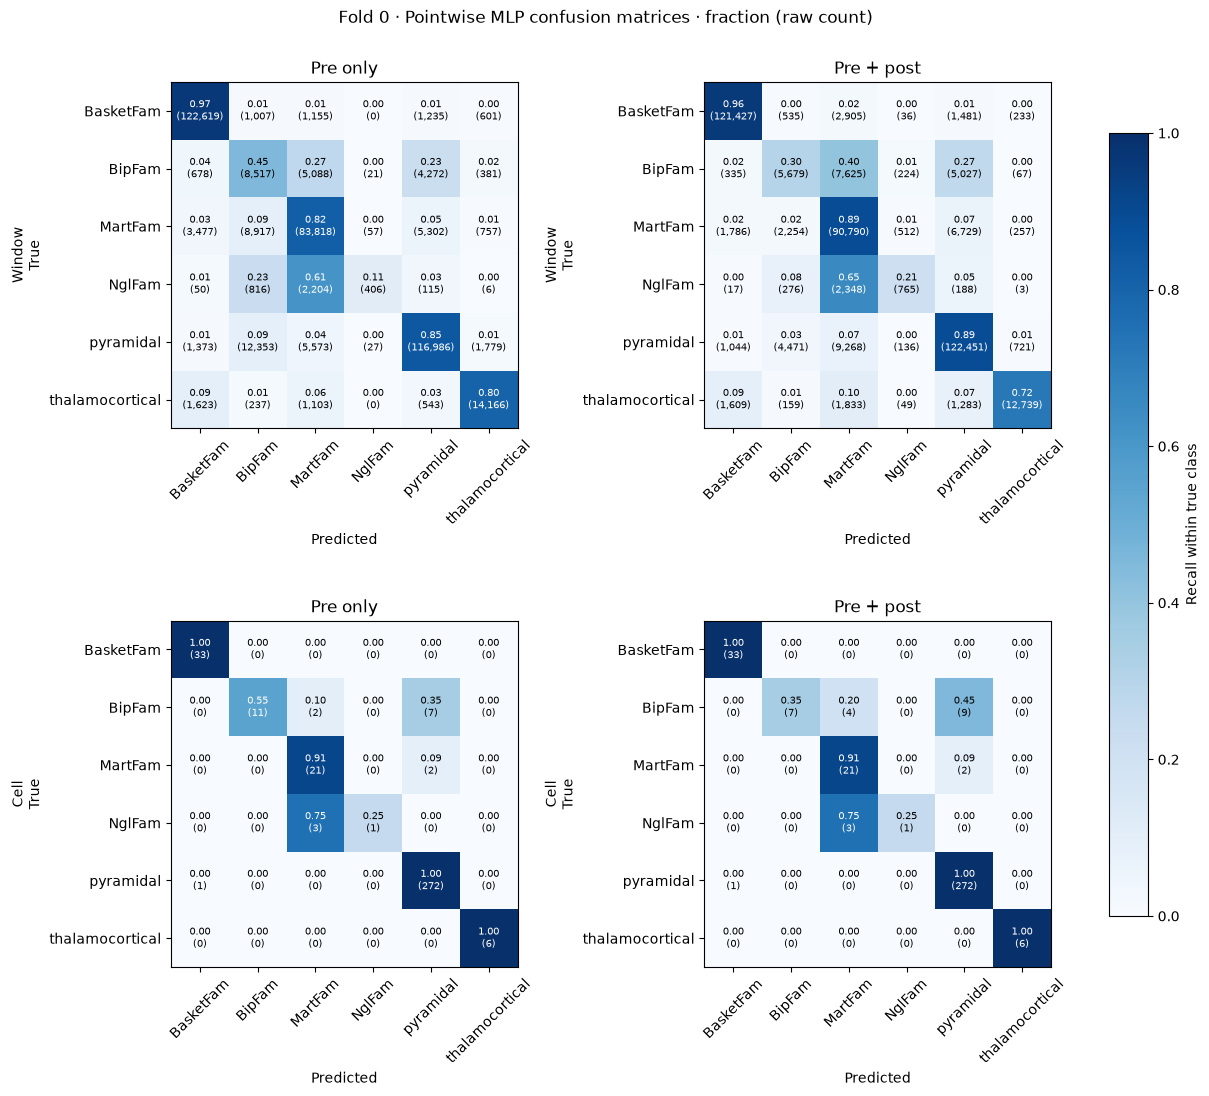

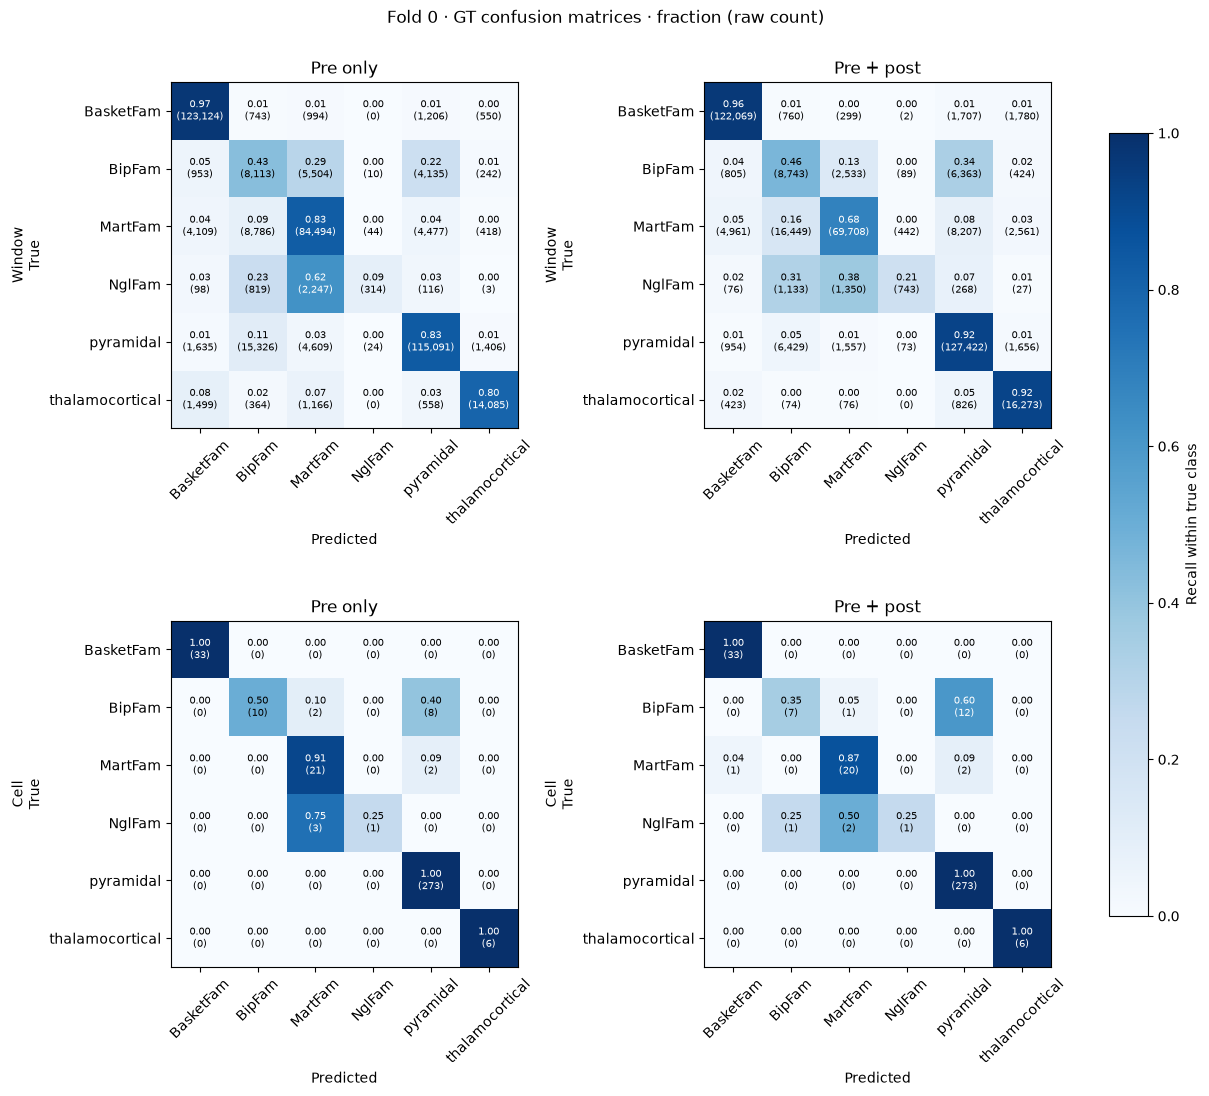

In [6]:
for fold in folds:
    for architecture in ARCHITECTURES:
        show_fold_figure(plot_confusions(payloads, fold, architecture), fold)

## Excluded postsynaptic sites

The CSV lists the **25 cohort sites with empty postsynaptic masks**, including both root IDs and postsynaptic XYZ coordinates in nanometres. Unresolved roots are also excluded from training. Eligibility is shared by pre-only and pre+post models, and exclusions are applied before deduplication.

In [7]:
excluded_path = ROOT / 'results/presynaptic/native_skeletons_pre_post/empty_mask_sites.csv'
excluded = pd.read_csv(excluded_path, dtype={
    'synapse_id': 'string', 'presynaptic_root_id': 'string', 'postsynaptic_root_id': 'string',
})
print(f'{len(excluded)} empty-mask sites; coordinates in nm')
display(excluded)
cache_marker = Path('/orcd/scratch/orcd/013/jcbliao/presynaptic_axons/native_skeletons_pre_post/scale16/k17/conf0.7/complete.json')
if cache_marker.exists():
    eligibility = json.loads(cache_marker.read_text())
    display(pd.Series({key: value for key, value in eligibility.items() if key.startswith('n_')}))

25 empty-mask sites; coordinates in nm


,synapse_id,presynaptic_root_id,postsynaptic_root_id,postsynaptic_x_nm,postsynaptic_y_nm,postsynaptic_z_nm,status,error
0,178832181,864691135939776309,864691135493990800,763616.0,741600.0,971880.0,empty_mask,No postsynaptic-root voxels in crop
1,182620510,864691135939776309,864691135493990800,764512.0,742344.0,974000.0,empty_mask,No postsynaptic-root voxels in crop
2,183326983,864691135742668395,864691135493990800,761568.0,798336.0,1062200.0,empty_mask,No postsynaptic-root voxels in crop
3,189700359,864691135349839831,864691135493990800,775008.0,743504.0,979960.0,empty_mask,No postsynaptic-root voxels in crop
4,189700885,864691135566979927,864691135493990800,776952.0,743448.0,979600.0,empty_mask,No postsynaptic-root voxels in crop
5,192349374,864691136067404440,864691135493990800,798680.0,735936.0,980400.0,empty_mask,No postsynaptic-root voxels in crop
6,196677680,864691136914541041,864691135493990800,790752.0,724104.0,970040.0,empty_mask,No postsynaptic-root voxels in crop
7,196849849,864691135695042751,864691135493990800,790616.0,782840.0,1059000.0,empty_mask,No postsynaptic-root voxels in crop
8,196959142,864691135619756943,864691135493990800,796472.0,747896.0,995640.0,empty_mask,No postsynaptic-root voxels in crop
9,200090035,864691135720572977,864691135493990800,815056.0,756320.0,1008880.0,empty_mask,No postsynaptic-root voxels in crop


n_cells                     1773
n_site_rows              2197243
n_unresolved_excluded          1
n_empty_mask_excluded         25
dtype: int64